# Label check: SEP-primary pseudo-labels (`vis_sep`) vs MER Q1

Before retraining the detectors, this validates **what we feed as training input**.
It compares the two VIS pseudo-label recipes against the clean Q1 MER catalogue on
the 10 seeded ECDFS tiles:

- **`vis_peak`** — current production labels (multi-scale peak-finder + SEP-assist + spike
  mask + bright-core + dedup + merge). What the current CenterNet/StemCenterNet learned.
- **`vis_sep`** — proposed labels (SEP primary + spike mask + bright-core + dedup, **no merge**).

Reads `paper_figures/_fig5_detection_cache.pkl` for the VIS images + MER positions
(no GPU). Saves `paper/figures/labelcheck_vis_sep_vs_mer.png`.

In [1]:
import sys, pickle
from pathlib import Path
import numpy as np
from scipy.spatial import cKDTree

def find_repo_root(start=None):
    start = (start or Path.cwd()).resolve()
    for c in [start, *start.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError('repo root')
REPO = find_repo_root()
for p in [REPO/'models', REPO/'models'/'detection', REPO/'models'/'astrometry2']:
    if str(p) not in sys.path: sys.path.insert(0, str(p))
from detection.dataset import _pseudo_labels_vis, _pseudo_labels_vis_sep, _vis_bright_core_and_spike_mask

CACHE = REPO/'paper_figures'/'_fig5_detection_cache.pkl'
OUT = REPO/'paper'/'figures'/'labelcheck_vis_sep_vs_mer.png'
MATCH_PX = 5.0          # 0.5" at VIS 0.1"/px
OVERLAY_TILE = 'tile_x01280_y00768_tract5063_patch_5'
ZOOM = (380, 820)
c = pickle.load(open(CACHE,'rb'))
print('tiles:', len(c['tiles_data']))

tiles: 10


In [2]:
def norm2px(cn, hw):
    h,w = hw
    return np.stack([cn[:,0]*(w-1), cn[:,1]*(h-1)],1).astype(np.float32) if len(cn) else np.zeros((0,2),np.float32)

def labels(vis, mode):
    fn = _pseudo_labels_vis_sep if mode=='vis_sep' else _pseudo_labels_vis
    ns = 2.0 if mode=='vis_sep' else 3.0
    cn,_,_,_ = fn(vis, ns, 1000)
    return cn

def comp_pur(pred, mer):
    # completeness = frac of MER with a pred within MATCH_PX; purity = frac of pred with a MER
    comp = float((cKDTree(pred).query(mer,k=1)[0] <= MATCH_PX).mean()) if len(pred) and len(mer) else 0.0
    pur  = float((cKDTree(mer).query(pred,k=1)[0] <= MATCH_PX).mean()) if len(pred) and len(mer) else 0.0
    return comp, pur

rows = {}
agg = {'vis_peak':[0,0,0,0,0], 'vis_sep':[0,0,0,0,0]}   # cnum,cden,pnum,pden,N
for st, td in c['tiles_data'].items():
    vis = td['vis'].astype(np.float32); hw = td['hw']; mer = td['lists'][4]
    for mode in ('vis_peak','vis_sep'):
        pred = norm2px(labels(vis, mode), hw)
        comp, pur = comp_pur(pred, mer)
        agg[mode][0]+=comp*len(mer); agg[mode][1]+=len(mer)
        agg[mode][2]+=pur*len(pred); agg[mode][3]+=len(pred); agg[mode][4]+=len(pred)
print(f"{'recipe':10s} {'mean N':>7} {'completeness':>13} {'purity':>8}")
for mode in ('vis_peak','vis_sep'):
    a=agg[mode]
    print(f"{mode:10s} {a[4]/len(c['tiles_data']):7.0f} {100*a[0]/a[1]:12.0f}% {100*a[2]/a[3]:7.0f}%")
POOL = {m:(100*agg[m][0]/agg[m][1], 100*agg[m][2]/agg[m][3], agg[m][4]/len(c['tiles_data'])) for m in agg}

recipe      mean N  completeness   purity
vis_peak       432           86%      47%
vis_sep        394           88%      53%


saved -> /home/shemmati/Work/Projects/JAISP/paper/figures/labelcheck_vis_sep_vs_mer.png


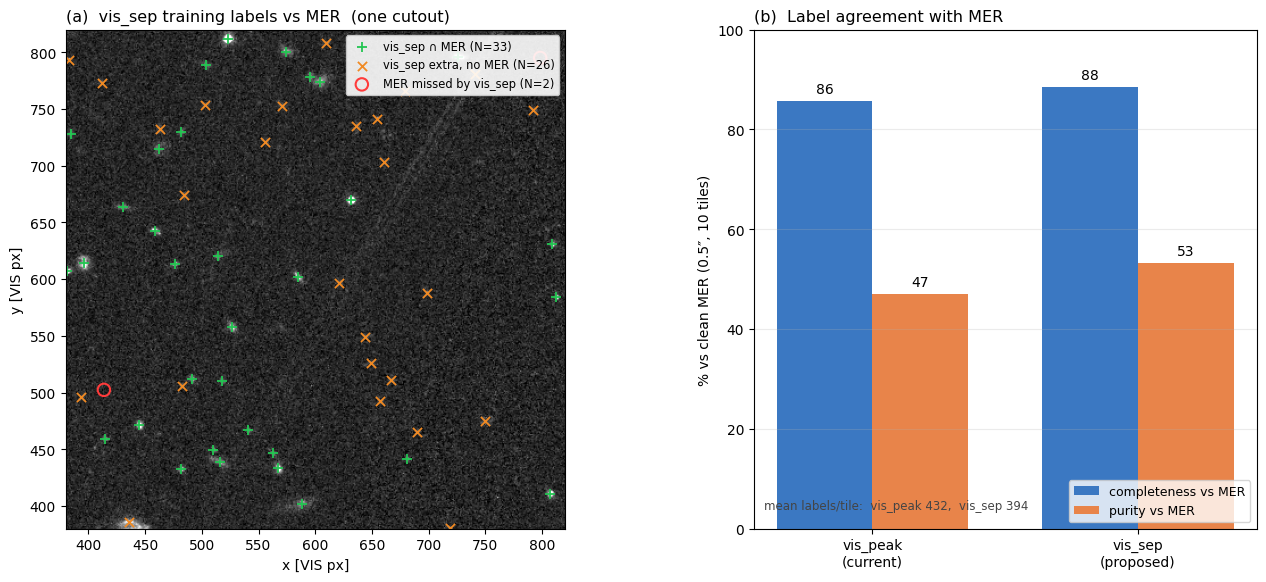

In [3]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

td = c['tiles_data'][OVERLAY_TILE]; vis = td['vis'].astype(np.float32); hw = td['hw']; mer = td['lists'][4]
sep_xy = norm2px(labels(vis,'vis_sep'), hw)
z0,z1 = ZOOM

def stretch(im, lo=1, hi=99.5):
    f=np.isfinite(im); a,b=np.percentile(im[f],[lo,hi]); b=max(b,a+1e-6)
    return np.clip((np.nan_to_num(im,nan=a)-a)/(b-a),0,1)

# categorize on the overlay tile
d_pred = cKDTree(mer).query(sep_xy,k=1)[0] if len(mer) and len(sep_xy) else np.full(len(sep_xy),9e9)
d_mer  = cKDTree(sep_xy).query(mer,k=1)[0] if len(mer) and len(sep_xy) else np.full(len(mer),9e9)
sep_match = sep_xy[d_pred<=MATCH_PX]; sep_extra = sep_xy[d_pred>MATCH_PX]
mer_miss  = mer[d_mer>MATCH_PX]

fig = plt.figure(figsize=(13.5,6.4))
gs = GridSpec(1,2,width_ratios=[1.25,1.0],wspace=0.22,left=0.04,right=0.97,top=0.9,bottom=0.12)

axL = fig.add_subplot(gs[0,0])
axL.imshow(stretch(vis),origin='lower',cmap='gray',vmin=0,vmax=1)
def insel(xy):
    return xy[(xy[:,0]>=z0)&(xy[:,0]<z1)&(xy[:,1]>=z0)&(xy[:,1]<z1)] if len(xy) else xy
s1,s2,s3 = insel(sep_match), insel(sep_extra), insel(mer_miss)
axL.scatter(s1[:,0],s1[:,1],s=46,marker='+',c='#23c552',lw=1.3,label=f'vis_sep ∩ MER (N={len(s1)})')
axL.scatter(s2[:,0],s2[:,1],s=44,marker='x',c='#f08a24',lw=1.3,label=f'vis_sep extra, no MER (N={len(s2)})')
axL.scatter(s3[:,0],s3[:,1],s=80,marker='o',facecolors='none',edgecolors='#ff3b3b',lw=1.5,label=f'MER missed by vis_sep (N={len(s3)})')
axL.set_xlim(z0,z1); axL.set_ylim(z0,z1); axL.set_xlabel('x [VIS px]'); axL.set_ylabel('y [VIS px]')
axL.set_title('(a)  vis_sep training labels vs MER  (one cutout)',loc='left',fontsize=11.5)
leg=axL.legend(loc='upper right',fontsize=8.3,framealpha=0.9,facecolor='white')
for t in leg.get_texts(): t.set_color('black')

axR = fig.add_subplot(gs[0,1])
labs=['vis_peak\n(current)','vis_sep\n(proposed)']; x=np.arange(2); w=0.36
comp=[POOL['vis_peak'][0],POOL['vis_sep'][0]]; pur=[POOL['vis_peak'][1],POOL['vis_sep'][1]]
b1=axR.bar(x-w/2,comp,w,label='completeness vs MER',color='#3b78c2')
b2=axR.bar(x+w/2,pur, w,label='purity vs MER',color='#e8844a')
for b in list(b1)+list(b2):
    axR.text(b.get_x()+b.get_width()/2,b.get_height()+1,f'{b.get_height():.0f}',ha='center',va='bottom',fontsize=10)
axR.set_xticks(x); axR.set_xticklabels(labs); axR.set_ylim(0,100); axR.set_ylabel('% vs clean MER (0.5″, 10 tiles)')
axR.set_title('(b)  Label agreement with MER',loc='left',fontsize=11.5)
axR.legend(fontsize=9,loc='lower right'); axR.grid(axis='y',alpha=0.25)
axR.text(0.02,0.04,f"mean labels/tile:  vis_peak {POOL['vis_peak'][2]:.0f},  vis_sep {POOL['vis_sep'][2]:.0f}",
         transform=axR.transAxes,fontsize=8.5,color='#444')

fig.savefig(OUT,dpi=300,bbox_inches='tight',facecolor='white'); print('saved ->',OUT); plt.show()